# L18 Notes: CIFAR-10 Image Processing for ML

### Set up imports

In [1]:
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score

### Load data

In [2]:
with open('cifar_data', 'rb') as file:
    cifar_data = pickle.load(file, encoding='latin1')

type(cifar_data)

/tmp/ipykernel_10186/2859084816.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  cifar_data = pickle.load(file, encoding='latin1')


dict

In [3]:
cifar_data.keys()

dict_keys(['batch_label', 'labels', 'data', 'filenames'])

### Look at first image

In [4]:
image_data = cifar_data['data']
label_data = cifar_data['labels']

image_data[0].shape

(3072,)

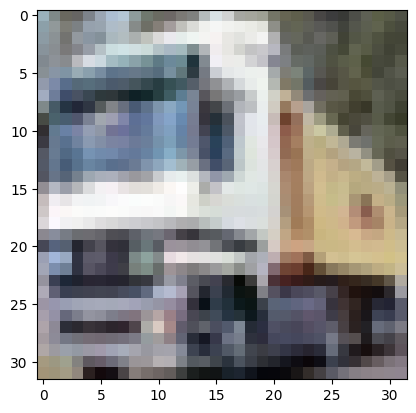

truck


In [5]:
# define a function to show an image and print a label
def show_image(image, label):
    # first convert the flattened image to 3d array
    img = image.reshape(3, 32, 32)

    # then, change the order of the dimensions
    img = img.transpose(1, 2, 0)

    # show the image
    plt.imshow(img)

    plt.show()

    # define list of labels
    label_names = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    # print the label
    print(label_names[label])

# test the function
show_image(image_data[1], label_data[1])

### Split the data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(image_data, label_data, random_state=42)

X_train.shape

(7500, 3072)

### Define and train the model

In [7]:
model = RandomForestClassifier(n_estimators=20, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

### Make predictions and evaluate accuracy

In [8]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f'accuracy: {acc * 100}%')

accuracy: 34.88%


# Activity

Goal: Make a model that performs better on the test data

Steps: 
1. Train a gradient boosting classifer with default params and measure accuracy

2. Perform grid search (use cv=2 to speed things up) with the random forest
Parameters to test:
n_estimators: [10, 20, 100]
max_features: ['sqrt', 'log2']
max_samples: [2000, 5000, None]

3. Analyze the mistakes of the best fitting model
Check the first 5 errors. Show the image, the predicted label, and the true label

### Train gradient boosting classifier and measure accuracy

In [9]:
# define the model
hgb_clf = HistGradientBoostingClassifier(random_state=42, max_iter=10, verbose=2)

# train the model
hgb_clf.fit(X_train, y_train)

# make test set predictions
y_pred_hgb = hgb_clf.predict(X_test)

# quantify accuracy
acc_hgb = accuracy_score(y_test, y_pred_hgb)

print(f'accuracy (gradient boosting): {acc_hgb * 100}%')

Binning 0.184 GB of training data: 3.929 s
Fitting gradient boosted rounds:
[1/10] 10 trees, 310 leaves (31 on avg), max depth = 12, in 3.153s
[2/10] 10 trees, 310 leaves (31 on avg), max depth = 16, in 3.321s
[3/10] 10 trees, 310 leaves (31 on avg), max depth = 14, in 3.105s
[4/10] 10 trees, 310 leaves (31 on avg), max depth = 14, in 3.174s
[5/10] 10 trees, 310 leaves (31 on avg), max depth = 15, in 3.213s
[6/10] 10 trees, 310 leaves (31 on avg), max depth = 14, in 3.136s
[7/10] 10 trees, 310 leaves (31 on avg), max depth = 13, in 3.385s
[8/10] 10 trees, 310 leaves (31 on avg), max depth = 17, in 3.350s
[9/10] 10 trees, 310 leaves (31 on avg), max depth = 15, in 3.294s
[10/10] 10 trees, 310 leaves (31 on avg), max depth = 13, in 3.204s
Fit 100 trees in 36.384 s, (3100 total leaves)
Time spent computing histograms: 15.409s
Time spent finding best splits:  16.624s
Time spent applying splits:      0.130s
Time spent predicting:           0.004s
accuracy (gradient boosting): 40.04%


### Run grid search to improve random forest fitting
2. Perform grid search (use cv=2 to speed things up) with the random forest
Parameters to test:
n_estimators: [10, 20, 100]
max_features: ['sqrt', 'log2']
max_samples: [1000, 2000, None]


In [10]:
# import the gridsearchCV
from sklearn.model_selection import GridSearchCV

# define the parameters to test
hyperparam_grid = {
    'n_estimators': [10, 20, 100],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [1000, 2000, None]
}

# define the grid search
grid = GridSearchCV(estimator=RandomForestClassifier(), param_grid=hyperparam_grid, cv=2, verbose=2)

# run the grid search
grid.fit(X_train, y_train)

Fitting 2 folds for each of 18 candidates, totalling 36 fits
[CV] END max_features=sqrt, max_samples=1000, n_estimators=10; total time=   0.5s
[CV] END max_features=sqrt, max_samples=1000, n_estimators=10; total time=   0.4s
[CV] END max_features=sqrt, max_samples=1000, n_estimators=20; total time=   0.9s
[CV] END max_features=sqrt, max_samples=1000, n_estimators=20; total time=   0.8s
[CV] END max_features=sqrt, max_samples=1000, n_estimators=100; total time=   4.2s
[CV] END max_features=sqrt, max_samples=1000, n_estimators=100; total time=   4.2s
[CV] END max_features=sqrt, max_samples=2000, n_estimators=10; total time=   0.9s
[CV] END max_features=sqrt, max_samples=2000, n_estimators=10; total time=   0.8s
[CV] END max_features=sqrt, max_samples=2000, n_estimators=20; total time=   1.6s
[CV] END max_features=sqrt, max_samples=2000, n_estimators=20; total time=   1.6s
[CV] END max_features=sqrt, max_samples=2000, n_estimators=100; total time=   7.9s
[CV] END max_features=sqrt, max_sa

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': ['sqrt', 'log2'], 'max_samples': [1000, 2000, ...], 'n_estimators': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

### Train a model with the best parameters and find the accuracy

In [11]:
print(f'The best params are {grid.best_params_}')

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)

acc_best

The best params are {'max_features': 'sqrt', 'max_samples': None, 'n_estimators': 100}


0.4072

### Look at the errors the best model is making
Loop over the y_pred_best and y_test together

check if there is a difference

if there is, then show the image, the true label, and the predicted label


In [ ]:
label_names = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
index = 0

for true_label, pred_label in zip(y_test, y_pred_best):
    
    # check for error
    if true_label != pred_label:

        # get the label names
        true_label_name = label_names[true_label]
        pred_label_name = label_names[pred_label]

        # print the label names
        print(true_label_name, pred_label_name)
        show_image(X_test[index], y_test[index])

    index = index + 1